_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: maroon'>*Jiseok Ryu,  Arlette Musanabera* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which?  Where and how did you use it? [Copilot, ChatGPT, Claude-Code etc.]* </span>

# Coding Lab 3

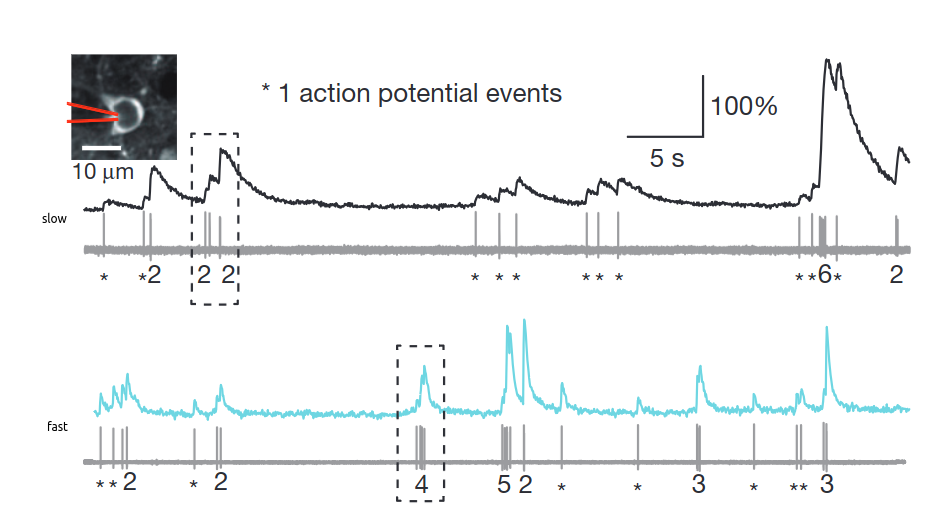

In this notebook you will work with 2 photon calcium recordings from mouse V1 and retina. For details see [Chen et al. 2013](https://www.nature.com/articles/nature12354) and [Theis et al. 2016](https://www.cell.com/neuron/pdf/S0896-6273(16)30073-3.pdf). Two-photon imaging is widely used to study computations in populations of neurons. 

In this exercise sheet we will study properties of different indicators and work on methods to infer spikes from calcium traces. All data is provided at a sampling rate of 100 Hz. For easier analysis, please resample it to 25 Hz. `scipy.signal.decimate` can help here, but note that it is only meant for continous signals. 

__Data__: Download the data file ```nds_cl_3_*.csv``` from ILIAS and save it in a subfolder ```../data/```. Note, some recordings were of shorter duration, hence their columns are padded. 

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.ndimage import uniform_filter1d
from scipy.signal import butter, filtfilt
from __future__ import annotations

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2026-05-04 13:49:28 SAST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
pandas    : 2.3.3
scipy     : 1.15.3
seaborn   : 0.13.2

Watermark: 2.6.0



In [4]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [5]:
# ogb dataset from Theis et al. 2016 Neuron
ogb_calcium = pd.read_csv("../data/nds_cl_3_ogb_calcium.csv", header=0)
ogb_spikes = pd.read_csv("../data/nds_cl_3_ogb_spikes.csv", header=0)
print(f"[OGB] calcium: {ogb_calcium.shape}, spikes: {ogb_spikes.shape}")

# gcamp dataset from Chen et al. 2013 Nature
gcamp_calcium = pd.read_csv("../data/nds_cl_3_gcamp2_calcium.csv", header=0)
gcamp_spikes = pd.read_csv("../data/nds_cl_3_gcamp2_spikes.csv", header=0)
print(f"[GCaMP] calcium: {gcamp_calcium.shape}, spikes: {gcamp_spikes.shape}")

# spike dataframe
ogb_spikes.head()

[OGB] calcium: (71986, 11), spikes: (71986, 11)
[GCaMP] calcium: (23973, 37), spikes: (23973, 37)


,0,1,2,3,4,5,6,7,8,9,10
0,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
1,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
2,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
3,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
4,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0


## Task 1: Visualization of calcium and spike recordings

We start again by plotting the raw data - calcium and spike traces in this case. One dataset has been recorded using the synthetic calcium indicator OGB-1 at population imaging zoom (~100 cells in a field of view) and the other one using the genetically encoded indicator GCamp6f zooming in on individual cells. Plot the traces of an example cell from each dataset to show how spikes and calcium signals are related. A good example cell for the OGB-dataset is cell 5. For the CGamp-dataset a good example is cell 6. Align the traces by eye (add a small offset to the plot) such that a valid comparison is possible and zoom in on a small segment of tens of seconds.

*Grading: 3 pts*

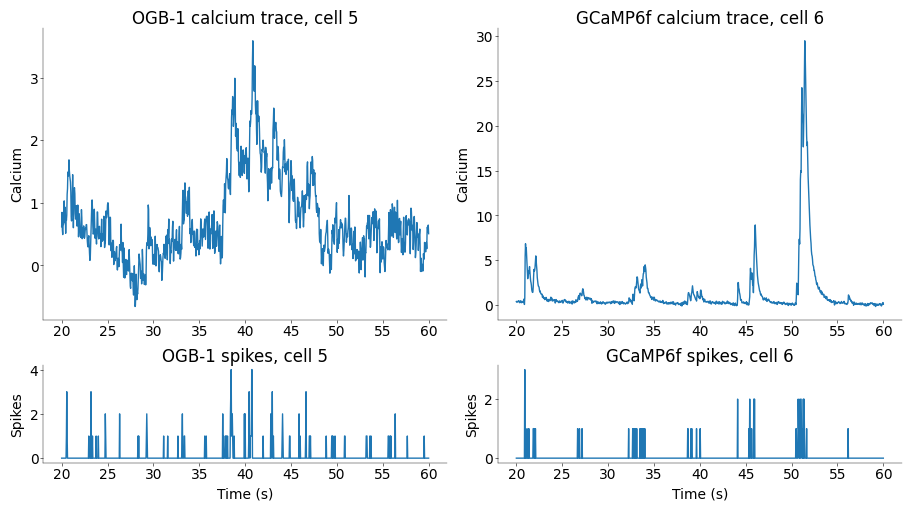

In [7]:
# --------------------------------
# Resample and prepare data (1 pt)
# --------------------------------

fs_original = 100
fs = 25
q = fs_original // fs

ogb_cell = 5
gcamp_cell = 6


def resample_pair(calcium_df, spikes_df, cell, q=4):
    calcium_raw = calcium_df.iloc[:, cell].dropna().to_numpy()
    spikes_raw = spikes_df.iloc[:, cell].dropna().to_numpy()

    n = min(len(calcium_raw), len(spikes_raw))
    n = (n // q) * q

    calcium_raw = calcium_raw[:n]
    spikes_raw = spikes_raw[:n]

    calcium_rs = signal.decimate(calcium_raw, q, zero_phase=True)

    spikes_rs = spikes_raw.reshape(-1, q).sum(axis=1)

    m = min(len(calcium_rs), len(spikes_rs))
    calcium_rs = calcium_rs[:m]
    spikes_rs = spikes_rs[:m]

    time = np.arange(m) / fs

    return time, calcium_rs, spikes_rs


t_ogb, ogb_cal, ogb_spk = resample_pair(ogb_calcium, ogb_spikes, ogb_cell, q)
t_gcamp, gcamp_cal, gcamp_spk = resample_pair(
    gcamp_calcium, gcamp_spikes, gcamp_cell, q
)

# Zoom windows in seconds
ogb_idx = (t_ogb >= 20) & (t_ogb <= 60)
gcamp_idx = (t_gcamp >= 20) & (t_gcamp <= 60)


fig, axs = plt.subplots(
    2, 2, figsize=(9, 5), height_ratios=[3, 1], layout="constrained"
)

# --------------------
# Plot OGB data (1 pt)
# --------------------
axs[0, 0].plot(t_ogb[ogb_idx], ogb_cal[ogb_idx])
axs[0, 0].set_title("OGB-1 calcium trace, cell 5")
axs[0, 0].set_ylabel("Calcium")

axs[1, 0].plot(t_ogb[ogb_idx], ogb_spk[ogb_idx])
axs[1, 0].set_title("OGB-1 spikes, cell 5")
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].set_ylabel("Spikes")

# ----------------------
# Plot GCamp data (1 pt)
# ----------------------
axs[0, 1].plot(t_gcamp[gcamp_idx], gcamp_cal[gcamp_idx])
axs[0, 1].set_title("GCaMP6f calcium trace, cell 6")
axs[0, 1].set_ylabel("Calcium")

axs[1, 1].plot(t_gcamp[gcamp_idx], gcamp_spk[gcamp_idx])
axs[1, 1].set_title("GCaMP6f spikes, cell 6")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Spikes")

plt.show()

The `OGB-1` signal is noisy and slow, with spikes only loosely reflected in the calcium trace, making the relationship hard to see clearly. In contrast, the `GCaMP6f` signal shows sharp calcium peaks that align well with spike bursts (e.g., around 50s), giving a much clearer and more precise correspondence between spikes and calcium activity.

## Bonus Task (Optional): Calcium preprocessing

To improve the quality of the inferred spikes, further preprocessing steps can undertaken. This includes filtering and smoothing of the calcium trace.

Implement a suitable filter and local averaging procedure as discussed in the lecture. Explain your choices and discuss how it helps!

_Grading: 1 BONUS point_

_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [11]:
def preprocess_calcium(trace, fs=25, cutoff=3, window_size=5):
    """
    Preprocess calcium trace using:
    1. Low-pass Butterworth filter to remove high-frequency noise
    2. Local averaging to smooth small fluctuations
    """
    trace = np.asarray(trace)

    # Low-pass filter
    nyquist = fs / 2
    b, a = butter(N=2, Wn=cutoff / nyquist, btype="low")
    filtered = filtfilt(b, a, trace)

    # Local averaging / smoothing
    smoothed = uniform_filter1d(filtered, size=window_size)

    return smoothed


# Preprocessing to the example traces
ogb_cal_preprocessed = preprocess_calcium(ogb_cal, fs=25, cutoff=3, window_size=5)
gcamp_cal_preprocessed = preprocess_calcium(gcamp_cal, fs=25, cutoff=3, window_size=5)

We applied a low-pass Butterworth filter followed by local averaging. The low-pass filter removes fast high-frequency noise that is unlikely to reflect real calcium dynamics, while the local averaging step smooths small fluctuations without completely removing the main calcium transients. This helps spike inference because the calcium peaks become cleaner and easier to distinguish from noise, especially for the noisier `OGB-1` trace.

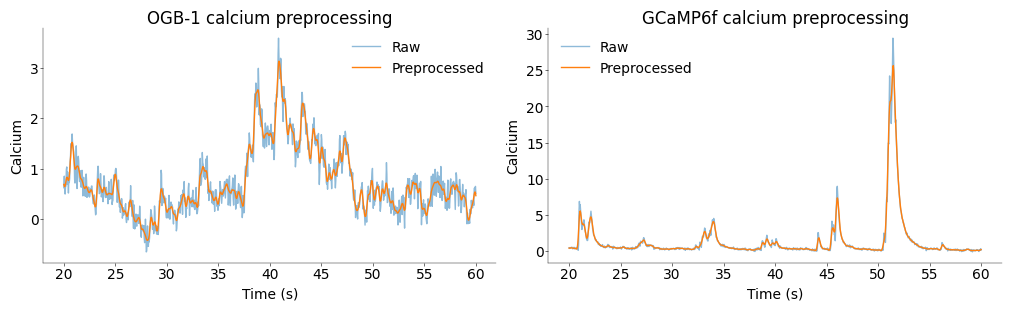

In [12]:
# Before and after preprocessing
fig, axs = plt.subplots(1, 2, figsize=(10, 3), layout="constrained")

axs[0].plot(t_ogb[ogb_idx], ogb_cal[ogb_idx], alpha=0.5, label="Raw")
axs[0].plot(t_ogb[ogb_idx], ogb_cal_preprocessed[ogb_idx], label="Preprocessed")
axs[0].set_title("OGB-1 calcium preprocessing")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Calcium")
axs[0].legend()

axs[1].plot(t_gcamp[gcamp_idx], gcamp_cal[gcamp_idx], alpha=0.5, label="Raw")
axs[1].plot(t_gcamp[gcamp_idx], gcamp_cal_preprocessed[gcamp_idx], label="Preprocessed")
axs[1].set_title("GCaMP6f calcium preprocessing")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Calcium")
axs[1].legend()

plt.show()

The preprocessing reduces noise and smooths the calcium traces a little, making the underlying signal clearer. This effect is more noticeable for `OGB-1`, where fluctuations are reduced, while `GCaMP6f` remains sharp but slightly smoother, helping preserve spike-related peaks while removing minor noise.

## Task 2: Simple deconvolution

It is clear from the above plots that the calcium events happen in relationship to the spikes. As a first simple algorithm implement a deconvolution approach like presented in the lecture in the function `deconv_ca`. Assume an exponential kernel where the decay constant depends on the indicator ($\tau_{OGB}= 0.5 s$, $\tau_{GCaMP}= 0.1 s$). Note there can be no negative rates! Plot the kernel as well as an example cell with true and deconvolved spike rates. Scale the signals such as to facilitate comparisons. You can use functions from `scipy` for this. Explain your results and your choice of kernel.

*Grading: 5 pts*


In [13]:
def deconv_ca(ca: np.ndarray, tau: float, dt: float) -> np.ndarray:
    """Compute the deconvolution of the calcium signal.

    Parameters
    ----------

    ca: np.array, (n_points,)
        Calcium trace

    tau: float
        decay constant of conv kernel

    dt: float
        sampling interval.

    Return
    ------

    sp_hat: np.array
    """

    # --------------------------------------------
    # apply devonvolution to calcium signal (1 pt)
    # --------------------------------------------

    ca = np.asarray(ca)
    ca = ca - np.percentile(ca, 5)

    # Exponential calcium kernel
    t_kernel = np.arange(0, 5 * tau, dt)
    kernel = np.exp(-t_kernel / tau)
    kernel = kernel / kernel.sum()

    # FFT-based deconvolution with small regularization
    n = len(ca) + len(kernel) - 1
    Ca = np.fft.rfft(ca, n=n)
    K = np.fft.rfft(kernel, n=n)

    eps = 1e-3
    sp_hat = np.fft.irfft(Ca * np.conj(K) / (np.abs(K) ** 2 + eps), n=n)
    sp_hat = sp_hat[: len(ca)]

    # No negative spike rates
    sp_hat[sp_hat < 0] = 0

    return sp_hat

In [14]:
# Parameters
dt = 1 / 25
tau_ogb = 0.5
tau_gcamp = 0.1

# Deconvolve example cells
ogb_deconv = deconv_ca(ogb_cal, tau=tau_ogb, dt=dt)
gcamp_deconv = deconv_ca(gcamp_cal, tau=tau_gcamp, dt=dt)

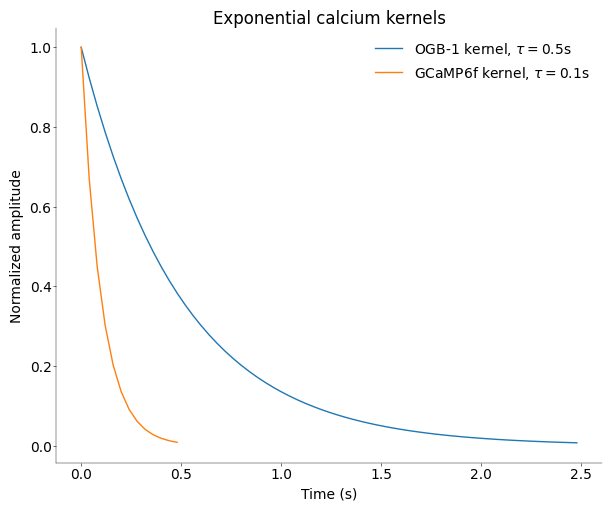

In [15]:
# -------------------------
# Plot the 2 kernels (1 pt)
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

t_ogb_kernel = np.arange(0, 5 * tau_ogb, dt)
kernel_ogb = np.exp(-t_ogb_kernel / tau_ogb)
kernel_ogb = kernel_ogb / kernel_ogb.max()

t_gcamp_kernel = np.arange(0, 5 * tau_gcamp, dt)
kernel_gcamp = np.exp(-t_gcamp_kernel / tau_gcamp)
kernel_gcamp = kernel_gcamp / kernel_gcamp.max()

ax.plot(t_ogb_kernel, kernel_ogb, label=r"OGB-1 kernel, $\tau=0.5$s")
ax.plot(t_gcamp_kernel, kernel_gcamp, label=r"GCaMP6f kernel, $\tau=0.1$s")

ax.set_title("Exponential calcium kernels")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized amplitude")
ax.legend()

plt.show()

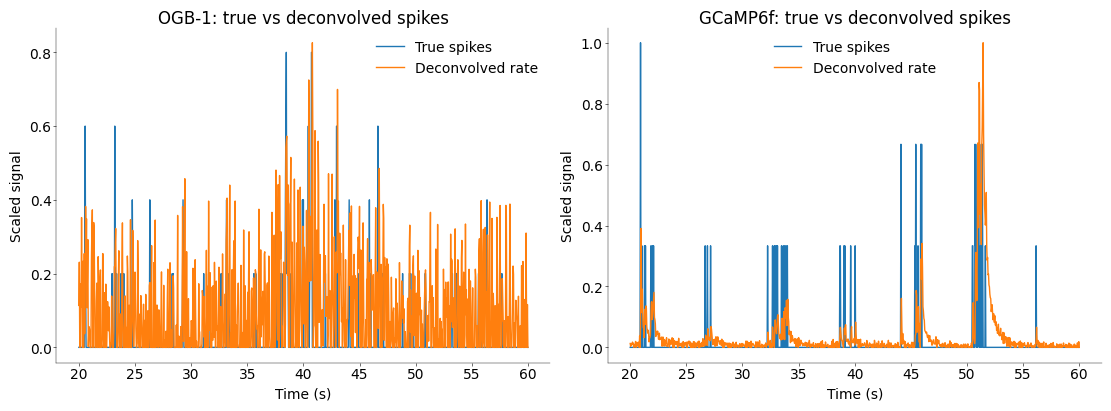

In [16]:
# ----------------------------------------------------
# Plot example cells with true and deconvolved spikes
# ----------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

# Scale for visual comparison
ogb_true_scaled = ogb_spk / np.max(ogb_spk) if np.max(ogb_spk) > 0 else ogb_spk
ogb_deconv_scaled = (
    ogb_deconv / np.max(ogb_deconv) if np.max(ogb_deconv) > 0 else ogb_deconv
)

gcamp_true_scaled = (
    gcamp_spk / np.max(gcamp_spk) if np.max(gcamp_spk) > 0 else gcamp_spk
)
gcamp_deconv_scaled = (
    gcamp_deconv / np.max(gcamp_deconv) if np.max(gcamp_deconv) > 0 else gcamp_deconv
)

axs[0].plot(t_ogb[ogb_idx], ogb_true_scaled[ogb_idx], label="True spikes")
axs[0].plot(t_ogb[ogb_idx], ogb_deconv_scaled[ogb_idx], label="Deconvolved rate")
axs[0].set_title("OGB-1: true vs deconvolved spikes")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Scaled signal")
axs[0].legend()

axs[1].plot(t_gcamp[gcamp_idx], gcamp_true_scaled[gcamp_idx], label="True spikes")
axs[1].plot(
    t_gcamp[gcamp_idx], gcamp_deconv_scaled[gcamp_idx], label="Deconvolved rate"
)
axs[1].set_title("GCaMP6f: true vs deconvolved spikes")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Scaled signal")
axs[1].legend()

plt.show()

### Questions (1 pt)
1) Explain how you constructed the kernels

_We constructed the kernels using an exponential decay function of the form `exp(-t/τ)`, where `τ` represents the decay constant of the indicator. The kernel was computed over a short time window and normalized to make comparisons easier. The choice reflects the biological behavior of calcium signals, which rise after a spike and then decay approximately exponentially._

2) How do the indicators / kernels compare?

_The `OGB-1` kernel decays much more slowly `(τ = 0.5 s)`, resulting in a broader and more spread-out response, while the GCaMP6f kernel decays quickly `(τ = 0.1 s)`, producing a sharper and more localized response. This means GCaMP6f preserves timing information better, whereas `OGB-1` smooths activity over longer periods._

3) What are pros and cons of each indicator?

_`OGB-1` is more robust to noise due to its slower decay, but it reduces temporal precision and makes it harder to distinguish closely spaced spikes. GCaMP6f provides higher temporal resolution and clearer spike alignment, but it is more sensitive to noise and may produce sharper but noisier estimates._

In [ ]:
# ----------------------------------------------------------------------
# Compare true and deconvolved spike rates for the OGB and GCamP cells.
# What differences do you notice? Does this align with your knowledge 
# about the indicators? (2 pts)
# ----------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# GCamp Cell


## Task 3: Run more complex algorithm

As reviewed in the lecture, a number of more complex algorithms for inferring spikes from calcium traces have been developed. Run an implemented algorithm on the data and plot the result. There is a choice of algorithms available, for example:

* Vogelstein: [oopsi](https://github.com/liubenyuan/py-oopsi)
* Theis: [c2s](https://github.com/lucastheis/c2s)
* Friedrich: [OASIS](https://github.com/j-friedrich/OASIS)

*Grading: 3 pts*



In [ ]:
# run this cell to download the oopsi.py file and put it in the same folder as this notebook
!wget https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py
import oopsi

In [ ]:
# ----------------------------------------------------------------------
# Apply one of the advanced algorithms to the OGB and GCamp Cells (1 pt)
# ----------------------------------------------------------------------

In [ ]:
# -------------------------------------------------------------------------------
# Plot the results for the OGB and GCamp Cells and describe the results (1+1 pts)
# -------------------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# GCamP Cell

## Task 4: Evaluation of algorithms

To formally evaluate the algorithms on the two datasets run the deconvolution algorithm and the more complex one on all cells and compute the correlation between true and inferred spikes. `DataFrames` from the `pandas` package are a useful tool for aggregating data and later plotting it. Create a dataframe with columns

* algorithm
* correlation
* indicator

and enter each cell. Plot the results using `stripplot` and/or `boxplot` in the `seaborn` package. Note these functions provide useful options for formatting the
plots. See their documentation, i.e. `sns.boxplot?`.

*Grading: 5 pts*


First, evaluate on OGB data and create OGB dataframe. Then repeat for GCamp and combine the two dataframes.

In [ ]:
# ----------------------------------------------------------
# Evaluate the algorithms on the OGB and GCamp cells (2 pts)
# ----------------------------------------------------------

In [ ]:
# ---------------------------------------------------------------------------------
# Construct the dataframe and print the first few rows as well as its shape (1 pts)
# ---------------------------------------------------------------------------------

Combine both dataframes. Plot the performance of each indicator and algorithm. You should only need a single plot for this.

In [ ]:
# ----------------------------------------------------------------------------
# Create Strip and Boxplot for both cells and algorithms Cell as described. (1 pt)
# Describe and explain the results briefly. (1 pt)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
